## Generation

---

Generation data describes electricity production, generation forecasts and
generation capacity.

### Typical units

- Generation: `MW`
- Installed capacity: `MW`
- Forecast generation: `MW`

### Typical applications

- Renewable generation forecasting
- Generation forecasting
- Capacity factor analysis
- Supply modelling
- Hydro-power analysis
- Electricity price forecasting


---

# Config

---

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.style.use("ggplot")

import os
from dotenv import load_dotenv

from entsoe import EntsoePandasClient

load_dotenv()

# ENTSOE Token
entsoe_token = os.getenv("ENTSOE_API_TOKEN")

# ENTSOE Client
entsoe_client = EntsoePandasClient(api_key=entsoe_token)

# Settings

---

In [2]:
# Location
country_capital = "Madrid"
country_code = "ES"

# Period
tz = f"Europe/{country_capital}"

now = pd.Timestamp.now(tz=tz)
today = now.normalize()

yesterday = today - pd.Timedelta(days=1)
last_week = today - pd.Timedelta(days=7)
last_month = today - pd.DateOffset(months=1)

tomorrow = today + pd.Timedelta(days=1)
day_after_tomorrow = today + pd.Timedelta(days=2)
next_week = today + pd.Timedelta(days=7)
next_month = today + pd.DateOffset(months=1)

# Mappings
---

In [11]:
psr_type = {
    'A03': 'Mixed',
    'A04': 'Generation',
    'A05': 'Load',
    'B01': 'Biomass',
    'B02': 'Fossil Brown coal/Lignite',
    'B03': 'Fossil Coal-derived gas',
    'B04': 'Fossil Gas',
    'B05': 'Fossil Hard coal',
    'B06': 'Fossil Oil',
    'B07': 'Fossil Oil shale',
    'B08': 'Fossil Peat',
    'B09': 'Geothermal',
    'B10': 'Hydro Pumped Storage',
    'B11': 'Hydro Run-of-river and poundage',
    'B12': 'Hydro Water Reservoir',
    'B13': 'Marine',
    'B14': 'Nuclear',
    'B15': 'Other renewable',
    'B16': 'Solar',
    'B17': 'Waste',
    'B18': 'Wind Offshore',
    'B19': 'Wind Onshore',
    'B20': 'Other',
    'B21': 'AC Link',
    'B22': 'DC Link',
    'B23': 'Substation',
    'B24': 'Transformer',
    'B25': 'Energy storage'
}

# EDA
---

###################################################################################
# .query_generation
(country_code, start=start, end=end, psr_type=None) -> pd.DataFrame

In [3]:
generation_solar = entsoe_client.query_generation(
    country_code=country_code,
    start=last_week,
    end=now,
    psr_type="B16")

Connection Error, retrying in 10 seconds


In [4]:
generation_solar.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 754 entries, 2026-08-20 00:00:00+02:00 to 2026-08-27 20:15:00+02:00
Freq: 15min
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Solar   754 non-null    float64
dtypes: float64(1)
memory usage: 11.8 KB


In [5]:
generation_solar.head()

,Solar
2026-08-20 00:00:00+02:00,608.0
2026-08-20 00:15:00+02:00,600.0
2026-08-20 00:30:00+02:00,592.0
2026-08-20 00:45:00+02:00,580.0
2026-08-20 01:00:00+02:00,580.0


In [6]:
generation_solar.tail()

,Solar
2026-08-27 19:15:00+02:00,8340.0
2026-08-27 19:30:00+02:00,6864.0
2026-08-27 19:45:00+02:00,5296.0
2026-08-27 20:00:00+02:00,3796.0
2026-08-27 20:15:00+02:00,2556.0


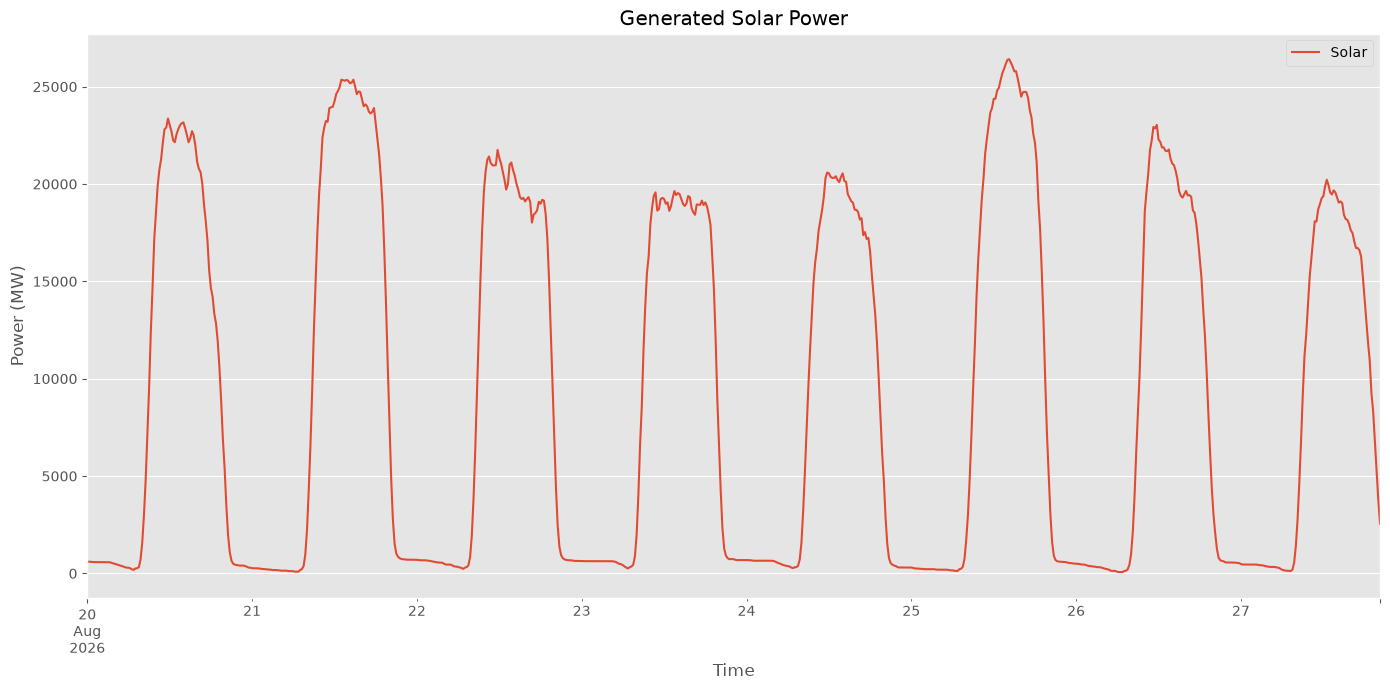

In [9]:
fig, ax = plt.subplots(figsize=(14, 7))

generation_solar.plot(ax=ax)

ax.set_title("Generated Solar Power")
ax.set_xlabel("Time")
ax.set_ylabel("Power (MW)")

fig.tight_layout()
plt.show()

###################################################################################
# .query_generation_per_plant
(country_code, start=start, end=end, psr_type=None, include_eic=False) -> pd.DataFrame

In [10]:
generation_solar_per_plant = entsoe_client.query_generation_per_plant(
    country_code=country_code,
    start=last_week,
    end=now,
    psr_type="B16",
    include_eic=True # EIC (Energy Identification Coding) Scheme
)

In [12]:
generation_solar_per_plant.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 672 entries, 2026-08-20 00:00:00+02:00 to 2026-08-26 23:45:00+02:00
Freq: 15min
Data columns (total 31 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   (RODRI, Solar, Actual Aggregated, 18W000000000AI2L)       672 non-null    float64
 1   (UF MULA, Solar, Actual Aggregated, 18W000000000F3CQ)     672 non-null    float64
 2   (NBALBOA, Solar, Actual Aggregated, 18W000000000H02A)     672 non-null    float64
 3   (PSFGUILLEN, Solar, Actual Aggregated, 18W000000000HBIJ)  672 non-null    float64
 4   (BVNIDA1, Solar, Actual Aggregated, 18W000000000J1FA)     672 non-null    float64
 5   (TALASOL, Solar, Actual Aggregated, 18W000000000JQVE)     672 non-null    float64
 6   (TALAYU, Solar, Actual Aggregated, 18W000000000JVZS)      672 non-null    float64
 7   (FV1014, Solar, Actual Aggregated, 18W000000000K82B)     

In [13]:
generation_solar_per_plant.head()

,RODRI,UF MULA,NBALBOA,PSFGUILLEN,BVNIDA1,TALASOL,TALAYU,FV1014,PV PUERTOR,VALDESOLAR,...,UF CASTAÑO,UF SERBAL,GST176,GST177,PEFLOR,TERRER,FCAPARA,FVCRODR,ARMEP,FAENAMA
,Solar,Solar,Solar,Solar,Solar,Solar,Solar,Solar,Solar,Solar,...,Solar,Solar,Solar,Solar,Solar,Solar,Solar,Solar,Solar,Solar
,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,...,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated
,18W000000000AI2L,18W000000000F3CQ,18W000000000H02A,18W000000000HBIJ,18W000000000J1FA,18W000000000JQVE,18W000000000JVZS,18W000000000K82B,18W000000000KBH9,18W000000000L45D,...,18W000000000SNJB,18W000000000SNL7,18W000000000T3KS,18W000000000T3MO,18W000000000TCWE,18W000000000TGC5,18W000000000TGPG,18W000000000THOF,18W000000000TRJW,18W000000000TRQI
2026-08-20 00:00:00+02:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-08-20 00:15:00+02:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-08-20 00:30:00+02:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-08-20 00:45:00+02:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-08-20 01:00:00+02:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
generation_solar_per_plant.tail()

,RODRI,UF MULA,NBALBOA,PSFGUILLEN,BVNIDA1,TALASOL,TALAYU,FV1014,PV PUERTOR,VALDESOLAR,...,UF CASTAÑO,UF SERBAL,GST176,GST177,PEFLOR,TERRER,FCAPARA,FVCRODR,ARMEP,FAENAMA
,Solar,Solar,Solar,Solar,Solar,Solar,Solar,Solar,Solar,Solar,...,Solar,Solar,Solar,Solar,Solar,Solar,Solar,Solar,Solar,Solar
,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,...,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated,Actual Aggregated
,18W000000000AI2L,18W000000000F3CQ,18W000000000H02A,18W000000000HBIJ,18W000000000J1FA,18W000000000JQVE,18W000000000JVZS,18W000000000K82B,18W000000000KBH9,18W000000000L45D,...,18W000000000SNJB,18W000000000SNL7,18W000000000T3KS,18W000000000T3MO,18W000000000TCWE,18W000000000TGC5,18W000000000TGPG,18W000000000THOF,18W000000000TRJW,18W000000000TRQI
2026-08-26 22:45:00+02:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-08-26 23:00:00+02:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-08-26 23:15:00+02:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-08-26 23:30:00+02:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-08-26 23:45:00+02:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


###################################################################################
# .query_generation_forecast
(country_code, start=start, end=end) -> pd.DataFrame

In [15]:
generation_fcst = entsoe_client.query_generation_forecast(
    country_code=country_code,
    start=last_week,
    end=next_week
)

In [16]:
generation_fcst.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 864 entries, 2026-08-20 00:00:00+02:00 to 2026-08-28 23:45:00+02:00
Freq: 15min
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Scheduled Aggregated   864 non-null    float64
 1   Scheduled Consumption  864 non-null    float64
dtypes: float64(2)
memory usage: 20.2 KB


In [17]:
generation_fcst.head()

,Scheduled Aggregated,Scheduled Consumption
2026-08-20 00:00:00+02:00,31558.0,4.4
2026-08-20 00:15:00+02:00,31248.0,4.4
2026-08-20 00:30:00+02:00,30982.4,0.0
2026-08-20 00:45:00+02:00,30577.2,0.0
2026-08-20 01:00:00+02:00,30160.4,0.0


In [18]:
generation_fcst.tail().T

,2026-08-28 22:45:00+02:00,2026-08-28 23:00:00+02:00,2026-08-28 23:15:00+02:00,2026-08-28 23:30:00+02:00,2026-08-28 23:45:00+02:00
Scheduled Aggregated,26626.4,25711.2,25610.4,25527.2,25335.2
Scheduled Consumption,4.4,4.4,4.4,4.4,4.4


<Axes: >

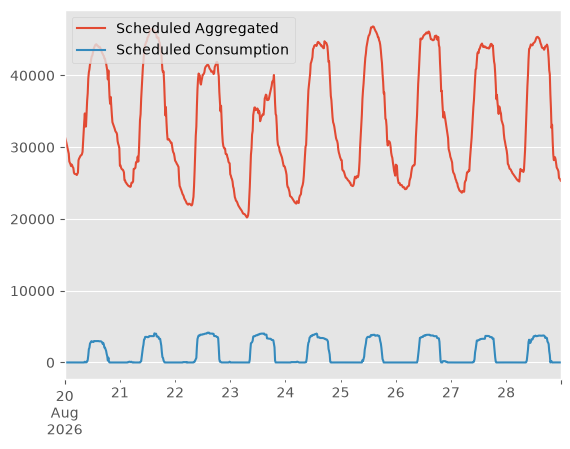

In [19]:
# generation_fcst["Scheduled Aggregated"] = generation_fcst["Scheduled Aggregated"]*0.25
generation_fcst.plot()

###################################################################################
# .query_wind_and_solar_forecast
(country_code, start=start, end=end, psr_type=None) -> pd.DataFrame

In [32]:
solar_fcst = entsoe_client.query_wind_and_solar_forecast(
    country_code=country_code,
    start=last_week,
    end=next_week,
    psr_type="B16"
)

In [33]:
solar_fcst.head()

,Solar
2026-08-20 00:00:00+02:00,392.0
2026-08-20 00:15:00+02:00,372.0
2026-08-20 00:30:00+02:00,344.0
2026-08-20 00:45:00+02:00,314.0
2026-08-20 01:00:00+02:00,271.0


In [34]:
solar_fcst.tail()

,Solar
2026-08-28 22:45:00+02:00,514.0
2026-08-28 23:00:00+02:00,526.0
2026-08-28 23:15:00+02:00,518.0
2026-08-28 23:30:00+02:00,502.0
2026-08-28 23:45:00+02:00,480.0


<Axes: >

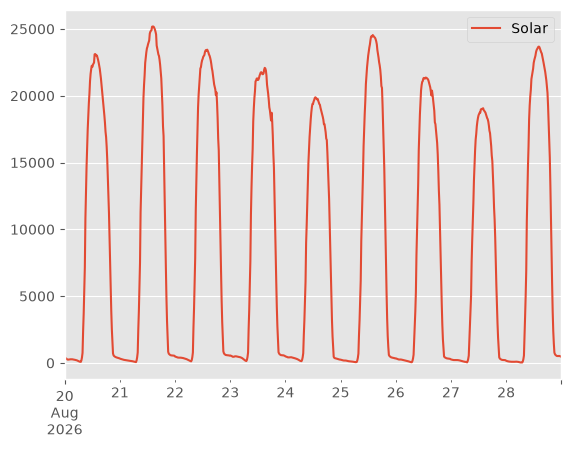

In [35]:
solar_fcst.plot()

In [37]:
wind_fcst = entsoe_client.query_wind_and_solar_forecast(
    country_code=country_code,
    start=last_week,
    end=next_week,
    psr_type="B19"
)

In [38]:
wind_fcst.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 864 entries, 2026-08-20 00:00:00+02:00 to 2026-08-28 23:45:00+02:00
Freq: 15min
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Wind Onshore  864 non-null    float64
dtypes: float64(1)
memory usage: 13.5 KB


In [39]:
wind_fcst.head()

,Wind Onshore
2026-08-20 00:00:00+02:00,7175.0
2026-08-20 00:15:00+02:00,7036.0
2026-08-20 00:30:00+02:00,6940.0
2026-08-20 00:45:00+02:00,6868.0
2026-08-20 01:00:00+02:00,6865.0


In [40]:
wind_fcst.tail()

,Wind Onshore
2026-08-28 22:45:00+02:00,3867.0
2026-08-28 23:00:00+02:00,3832.0
2026-08-28 23:15:00+02:00,3813.0
2026-08-28 23:30:00+02:00,3798.0
2026-08-28 23:45:00+02:00,3786.0


<Axes: >

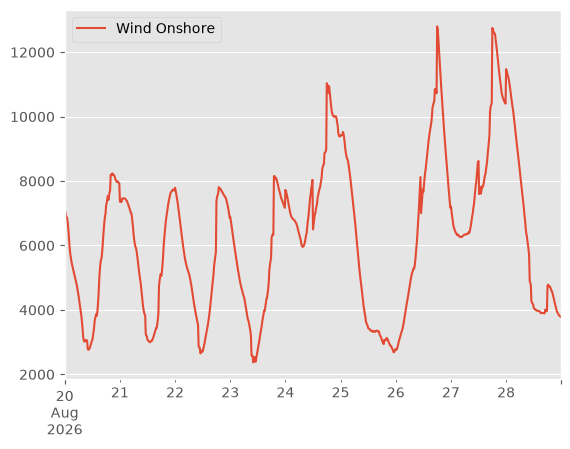

In [41]:
wind_fcst.plot()

###################################################################################
# .query_intraday_wind_and_solar_forecast
(country_code, start=start, end=end, psr_type=None) -> pd.DataFrame

In [44]:
intraday_solar_fcst = entsoe_client.query_intraday_wind_and_solar_forecast(
    country_code=country_code,
    start=last_week,
    end=next_week,
    psr_type="B16"
)

In [45]:
intraday_solar_fcst.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 864 entries, 2026-08-20 00:00:00+02:00 to 2026-08-28 23:45:00+02:00
Freq: 15min
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Solar   864 non-null    float64
dtypes: float64(1)
memory usage: 13.5 KB


In [47]:
intraday_solar_fcst.head()

,Solar
2026-08-20 00:00:00+02:00,493.0
2026-08-20 00:15:00+02:00,461.0
2026-08-20 00:30:00+02:00,423.0
2026-08-20 00:45:00+02:00,385.0
2026-08-20 01:00:00+02:00,390.0


In [46]:
intraday_solar_fcst.tail()

,Solar
2026-08-28 22:45:00+02:00,510.0
2026-08-28 23:00:00+02:00,503.0
2026-08-28 23:15:00+02:00,497.0
2026-08-28 23:30:00+02:00,491.0
2026-08-28 23:45:00+02:00,484.0


<Axes: >

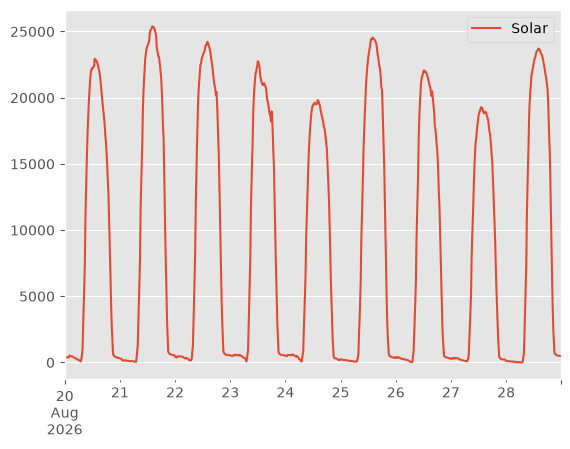

In [48]:
intraday_solar_fcst.plot()

In [49]:
intraday_wind_fcst = entsoe_client.query_intraday_wind_and_solar_forecast(
    country_code=country_code,
    start=last_week,
    end=next_week,
    psr_type="B19"
)

In [50]:
intraday_wind_fcst.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 864 entries, 2026-08-20 00:00:00+02:00 to 2026-08-28 23:45:00+02:00
Freq: 15min
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Wind Onshore  864 non-null    float64
dtypes: float64(1)
memory usage: 13.5 KB


In [51]:
intraday_wind_fcst.head()

,Wind Onshore
2026-08-20 00:00:00+02:00,8221.0
2026-08-20 00:15:00+02:00,7955.0
2026-08-20 00:30:00+02:00,7695.0
2026-08-20 00:45:00+02:00,7446.0
2026-08-20 01:00:00+02:00,7229.0


In [52]:
intraday_wind_fcst.tail()

,Wind Onshore
2026-08-28 22:45:00+02:00,4077.0
2026-08-28 23:00:00+02:00,3988.0
2026-08-28 23:15:00+02:00,3933.0
2026-08-28 23:30:00+02:00,3895.0
2026-08-28 23:45:00+02:00,3876.0


<Axes: >

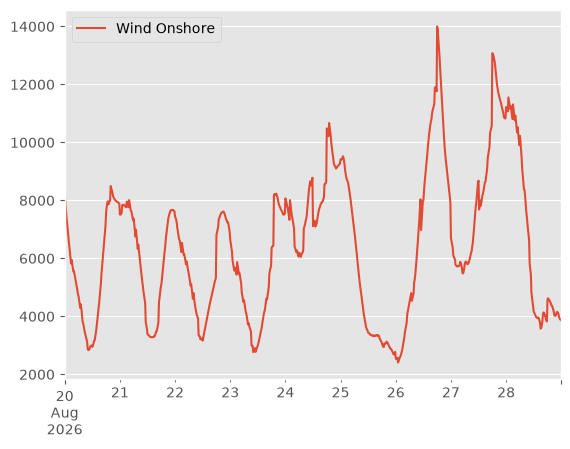

In [53]:
intraday_wind_fcst.plot()

###################################################################################
# .query_aggregate_water_reservoirs_and_hydro_storage
(country_code, start=start, end=end) -> pd.Series

In [25]:
aggregate_water_reservoirs_and_hydro_storage = entsoe_client.query_aggregate_water_reservoirs_and_hydro_storage(
    country_code=country_code,
    start=last_week,
    end=today)

In [21]:
aggregate_water_reservoirs_and_hydro_storage.info()

<class 'pandas.Series'>
DatetimeIndex: 1 entries, 2026-08-16 22:00:00+00:00 to 2026-08-16 22:00:00+00:00
Freq: 7D
Series name: None
Non-Null Count  Dtype  
--------------  -----  
1 non-null      float64
dtypes: float64(1)
memory usage: 16.0 bytes


In [22]:
aggregate_water_reservoirs_and_hydro_storage.head()

2026-08-16 22:00:00+00:00    11395265.0
Freq: 7D, dtype: float64

###################################################################################
# .query_installed_generation_capacity
(country_code, start=start, end=end, psr_type=None) -> pd.DataFrame

<p>The sum of installed net generation capacity (MW) for all existing production units equalling or exceeding 1 MW of installed generation capacity, per production type.</p>

In [26]:
installed_generation_capacity = entsoe_client.query_installed_generation_capacity(
    country_code=country_code,
    start=last_week,
    end=next_week,
    psr_type=None
)

In [27]:
installed_generation_capacity.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1 entries, 2026-01-02 00:00:00+01:00 to 2026-01-02 00:00:00+01:00
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Biomass                          1 non-null      float64
 1   Energy storage                   1 non-null      float64
 2   Fossil Brown coal/Lignite        1 non-null      float64
 3   Fossil Coal-derived gas          1 non-null      float64
 4   Fossil Gas                       1 non-null      float64
 5   Fossil Hard coal                 1 non-null      float64
 6   Fossil Oil                       1 non-null      float64
 7   Fossil Oil shale                 1 non-null      float64
 8   Fossil Peat                      1 non-null      float64
 9   Geothermal                       1 non-null      float64
 10  Hydro Pumped Storage             1 non-null      float64
 11  Hydro Run-of-river and poundage  1 non-null     

In [28]:
installed_generation_capacity.T

,2026-01-02 00:00:00+01:00
Biomass,753.4
Energy storage,31.6
Fossil Brown coal/Lignite,0.0
Fossil Coal-derived gas,0.0
Fossil Gas,29920.8
Fossil Hard coal,1258.1
Fossil Oil,726.2
Fossil Oil shale,0.0
Fossil Peat,0.0
Geothermal,0.0


###################################################################################
# .query_installed_generation_capacity_per_unit
(country_code, start=start, end=end, psr_type=None) -> pd.DataFrame

<p>Installed capacities at the beginning of the year and current (actual date) installed capacities for all production units (including planned).</p>

In [29]:
installed_generation_capacity_per_unit = entsoe_client.query_installed_generation_capacity_per_unit(
    country_code=country_code,
    start=last_week,
    end=next_week,
    psr_type=None
)

In [30]:
installed_generation_capacity_per_unit.info()

<class 'pandas.DataFrame'>
Index: 1 entries, 18WPVENT2--12342 to 18WPVENT2--12342
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Bidding Zone                   1 non-null      object
 1   Installed Capacity [MW]        1 non-null      object
 2   Name                           1 non-null      str   
 3   Production Type                1 non-null      str   
 4   Start                          1 non-null      object
 5   Voltage Connection Level [kV]  1 non-null      object
dtypes: object(4), str(2)
memory usage: 97.0+ bytes


In [31]:
installed_generation_capacity_per_unit.T

,18WPVENT2--12342
Bidding Zone,10YES-REE------0
Installed Capacity [MW],414
Name,Plana del Vent
Production Type,Fossil Gas
Start,2025-12-31 23:00:00+00:00
Voltage Connection Level [kV],400


###################################################################################
# .query_generation_import
(country_code, start, end) -> pd.DataFrame

In [42]:
generation_import = entsoe_client.query_generation_import(
    country_code=country_code,
    start=last_week,
    end=today
)

In [43]:
generation_import.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 672 entries, 2026-08-20 00:00:00+02:00 to 2026-08-26 23:45:00+02:00
Freq: 15min
Data columns (total 16 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   (Generation, Biomass)                          672 non-null    float64
 1   (Generation, Energy storage)                   672 non-null    float64
 2   (Generation, Fossil Gas)                       672 non-null    float64
 3   (Generation, Fossil Oil)                       672 non-null    float64
 4   (Generation, Hydro Pumped Storage)             672 non-null    float64
 5   (Generation, Hydro Run-of-river and poundage)  672 non-null    float64
 6   (Generation, Hydro Water Reservoir)            672 non-null    float64
 7   (Generation, Nuclear)                          672 non-null    float64
 8   (Generation, Other)                            672 non-null    float64
 9   (Gen

###################################################################################
# .query_aggregate_water_reservoirs_and_hydro_storage
(country_code, start=start, end=end) -> pd.Series

In [54]:
aggregate_water_reservoirs_and_hydro_storage = entsoe_client.query_aggregate_water_reservoirs_and_hydro_storage(
    country_code=country_code,
    start=last_week, 
    end=today, 
)

In [56]:
aggregate_water_reservoirs_and_hydro_storage.info()

<class 'pandas.Series'>
DatetimeIndex: 1 entries, 2026-08-16 22:00:00+00:00 to 2026-08-16 22:00:00+00:00
Freq: 7D
Series name: None
Non-Null Count  Dtype  
--------------  -----  
1 non-null      float64
dtypes: float64(1)
memory usage: 16.0 bytes


In [57]:
aggregate_water_reservoirs_and_hydro_storage

2026-08-16 22:00:00+00:00    11395265.0
Freq: 7D, dtype: float64